# Penguin Linear Regression by Analytical Solution

In [149]:
# read the variables: class label and features

def string2float(item):
    return float(item) if item != '' else None

def read_strings(filename, col):
    with open(filename) as f:
        lines = f.readlines()
    values = [line.strip().split(',')[col] for line in lines[1:]]
    return values

def read_floats(filename, col):
    with open(filename) as f:
        lines = f.readlines()
    values = [string2float(line.strip().split(',')[col]) for line in lines[1:]]
    return values

In [151]:
filename = 'data/palmer-penguins/palmer-penguins-train.txt'

flipper_lengths =  read_floats(filename, col=4)

body_masses = read_floats(filename, col=5)

In [153]:
# convert list to numeric vectors

import numpy as np

x1 = np.array(flipper_lengths)
y = np.array(body_masses)

print(x1)
print(y)

[181. 195. 193. 181. 193. 186. 182. 198. 195. 184. 174. 189. 180. 183.
 172. 178. 188. 195. 190. 181. 182. 186. 185. 182. 190. 186. 190. 187.
 186. 181. 185. 185. 184. 195. 190. 190. 196. 190. 191. 187. 189. 187.
 191. 190. 189. 202. 185. 187. 190. 178. 192. 183. 193. 199. 181. 198.
 193. 191. 188. 189. 187. 176. 186. 191. 191. 190. 193. 187. 191. 185.
 193. 188. 192. 190. 195. 187. 211. 210. 215. 211. 209. 214. 214. 210.
 210. 209. 218. 213. 215. 216. 210. 222. 207. 220. 213. 208. 208. 210.
 222. 210. 213. 210. 210. 217. 208. 208. 208. 214. 219. 214. 220. 216.
 221. 216. 209. 215. 212. 212. 212. 218. 212. 218. 212. 214. 216. 203.
 219. 215. 216. 210. 208. 216. 213. 217. 217. 214. 215. 212. 192. 193.
 197. 178. 195. 193. 185. 190. 197. 190. 181. 187. 195. 200. 191. 187.
 187. 195. 195. 192. 210. 196. 196. 190. 187. 199. 193. 187. 191. 202.
 206. 195. 202. 210.]
[3750. 3250. 3450. 3625. 3475. 3300. 3200. 4400. 3450. 3325. 3400. 3800.
 3800. 3550. 3150. 3250. 3300. 3325. 3950. 3300. 3150

In [155]:
print(type(x1))
print(x1.shape)
print(x1.size)

<class 'numpy.ndarray'>
(172,)
172


In [157]:
print(type(y))
print(y.shape)
print(y.size)

<class 'numpy.ndarray'>
(172,)
172


In [159]:
# create x0

x0 = np.ones(x1.shape)

print(x0)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


In [163]:
X = np.concatenate((x0, x1))

X = np.concatenate((x0.reshape(x0.size, 1),
                    x1.reshape(x1.size, 1)), axis=1)

print(X.shape)
print(X[:10])

(172, 2)
[[  1. 181.]
 [  1. 195.]
 [  1. 193.]
 [  1. 181.]
 [  1. 193.]
 [  1. 186.]
 [  1. 182.]
 [  1. 198.]
 [  1. 195.]
 [  1. 184.]]


In [167]:
X = np.stack((x0, x1), axis=0)

print(X.shape)
print(X[:,:10])

(2, 172)
[[  1.   1.   1.   1.   1.   1.   1.   1.   1.   1.]
 [181. 195. 193. 181. 193. 186. 182. 198. 195. 184.]]


In [169]:
X = np.stack((x0, x1), axis=0).transpose()

print(X.shape)
print(X[:10])

(172, 2)
[[  1. 181.]
 [  1. 195.]
 [  1. 193.]
 [  1. 181.]
 [  1. 193.]
 [  1. 186.]
 [  1. 182.]
 [  1. 198.]
 [  1. 195.]
 [  1. 184.]]


In [171]:
X = np.stack((x0, x1), axis=1)

print(X.shape)
print(X[:10])

(172, 2)
[[  1. 181.]
 [  1. 195.]
 [  1. 193.]
 [  1. 181.]
 [  1. 193.]
 [  1. 186.]
 [  1. 182.]
 [  1. 198.]
 [  1. 195.]
 [  1. 184.]]


$\mathbf{w} = (\mathbf{X}^\mathrm{T} \mathbf{X})^{-1} \mathbf{X}^\mathrm{T} \mathbf{y}$

In [173]:
# print(X.transpose() * X)? Incorrect

result = np.matmul(X.transpose(), X)

print(result)

[[1.720000e+02 3.409100e+04]
 [3.409100e+04 6.784983e+06]]


In [175]:
# https://numpy.org/doc/2.1/reference/generated/numpy.linalg.inv.html#

result = np.matmul(X.transpose(), X)
result = np.linalg.inv(result)

print(result)

[[ 1.40744068e+00 -7.07165519e-03]
 [-7.07165519e-03  3.56787625e-05]]


In [177]:
result = np.matmul(X.transpose(), X)
result = np.linalg.inv(result)
result = np.matmul(result, X.transpose())
result = np.matmul(result, y)
w = result

print(w)

[-5505.90432698    47.4726627 ]


(2700.0, 5700.0)

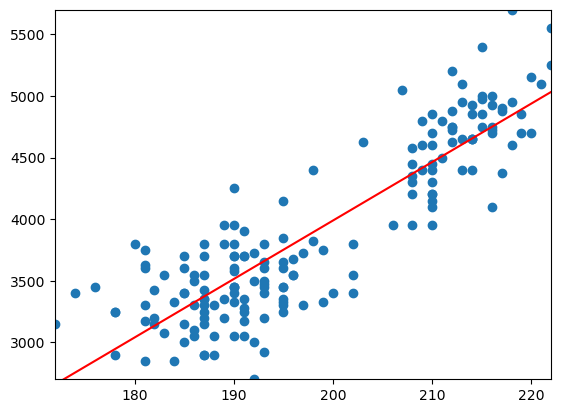

In [179]:
import matplotlib.pyplot as plt

plt.scatter(x1, y)

plt.axline(xy1=(0, w[0]), slope=w[1], color='red')

plt.xlim(np.min(x1), np.max(x1))
plt.ylim(np.min(y), np.max(y))

In [181]:
# training set evaluation

y_pred = np.matmul(X, w)

diff = y - y_pred
mse = np.mean(diff ** 2)

print(mse)
print(np.mean(y), np.sqrt(mse), np.sqrt(mse)/np.mean(y))

112607.97613696932
3903.343023255814 335.57111934278447 0.08597018436337207


In [139]:
# test data

filename = 'data/palmer-penguins/palmer-penguins-test.txt'

flipper_lengths =  read_floats(filename, col=4)
body_masses = read_floats(filename, col=5)

x1 = np.array(flipper_lengths)
y = np.array(body_masses)

idx = (x1 != None) & (y != None)
x1 = x1[idx]
y = y[idx]

x0 = np.ones(x1.shape)
X = np.stack((x0, x1), axis=1)

(2975.0, 6300.0)

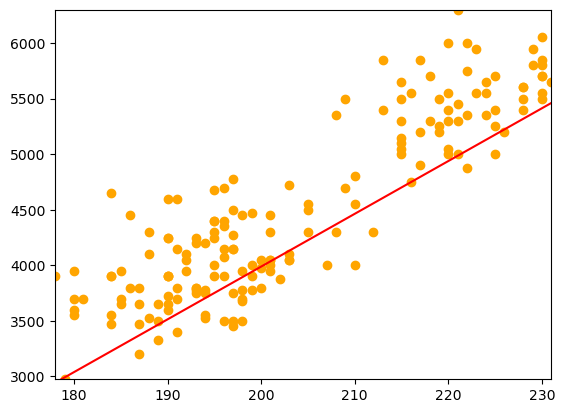

In [141]:
plt.scatter(x1, y, color='orange')

plt.axline(xy1=(0, w[0]), slope=w[1], color='red')

plt.xlim(np.min(x1), np.max(x1))
plt.ylim(np.min(y), np.max(y))

In [ ]:
y_pred = np.matmul(X, w)

diff = y - y_pred
mse = np.mean(diff ** 2)

print(mse)
print(np.mean(y), np.sqrt(mse), np.sqrt(mse)/np.mean(y))

256840.66721463288
4503.676470588235 506.7945019577786 0.11252906492450268
